# Imports

In [1]:
######################
# Calculate CAPE
# 2026.4.27
# Mu-Ting Chien
######################
import numpy as np
import xarray as xr
import os
from metpy.calc import cape_cin, dewpoint_from_relative_humidity, parcel_profile
from metpy.units import units

import logging

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    # filename="aquaplanet_logs/cape_calculation.log",      # <— write logs here
    # filemode="a",               # "a" = append (default), "w" = overwrite
)

logger = logging.getLogger(__name__)

from time import time as current_time
def seconds_to_hms(seconds):
    hours = seconds // 3600
    minutes = (seconds % 3600) // 60
    secs = seconds % 60
    return f"{int(hours)}hr {int(minutes)}m {secs:.2f}s"

# Climatological Cape

In [99]:
##############
# 1. Load data
#################
dir_in = '/glade/campaign/univ/uwas0114/processed_pcoord/'
expname_list = list(['-4K','CTL','4K'])
fout_list = list(['m4K','ctl','p4K'])

Ptop_all = np.array([75, 100, 125])*100 # Find tropoppause for each exp!

climatological_CAPE = {}
climatological_CIN = {}

def add_absolute_time(ds, year_index):
    nt = ds.sizes['time']
    new_time = xr.DataArray(
        np.arange(year_index * nt, (year_index + 1) * nt),
        dims='time'
    )
    return ds.assign_coords(time=new_time)

for iexp in range(0, 3):#3): # 0, 3
# iexp = 0
    
    dir_in_sub = dir_in + fout_list[iexp]+'/'

    # for iyr in range(3, 6):#6): # 3, 6
    iyr = 3

    yy_str = f"{iyr:04d}"
    logger.info('Start calculating CAPE for :'+ expname_list[iexp]+','+yy_str)

    latitude_bounds = slice(-15,15) # narrow lat band for CAPE calculation
    # Load T
    fname = dir_in_sub + fout_list[iexp]+'_T_yr'+yy_str+'.nc'
    # ds    = xr.open_dataset(fname).sel(lat=latitude_bounds)
    temperature_fname = glob.glob(dir_in_sub + fout_list[iexp]+'_T_yr*.nc')
    # ds = xr.open_mfdataset(temperature_fname)
    datasets = []
    for i, f in enumerate(sorted(temperature_fname)):
        d = xr.open_dataset(f)
        datasets.append(add_absolute_time(d, i))

    ds = xr.concat(datasets, dim='time')
    T = ds['T']
    time = ds['time']
    lat  = ds['lat']
    lon  = ds['lon']
    plev = ds['plev']
    logger.info('T loaded')

    # Load q
    fname = dir_in_sub + fout_list[iexp]+'_Q_yr'+yy_str+'.nc'
    # ds    = xr.open_dataset(fname).sel(lat=latitude_bounds)
    moisture_fname = glob.glob(dir_in_sub + fout_list[iexp]+'_Q_yr*.nc')
    # ds = xr.open_mfdataset(moisture_fname)
    datasets = []
    for i, f in enumerate(sorted(moisture_fname)):
        d = xr.open_dataset(f)
        datasets.append(add_absolute_time(d, i))

    ds = xr.concat(datasets, dim='time')
    q = ds['Q']
    logger.info('Q loaded')

    # Define CC equation
    epsilon = 0.622
    e = 6.1094*np.exp( 17.625*(T-273.15)/(T-273.15+243.04) ) # hPa
    # plev_large = np.tile(plev, (np.size(T,0), np.size(T, 1), np.size(T, 2), 1))
    # print(np.shape(plev_large))
    #for ilev in range(0, np.size(plev)):
    #    if ilev == 0:
    #        RH = np.empty([np.size(T,0), np.size(T, 1), np.size(T, 2), np.size(T, 3)])
    RH = q/( epsilon*e/e.plev )
    logger.info("RH calculated")

    del q
    # Calculate CAPE
    RH_r = RH[:,:,:,::-1] * units.dimensionless
    del RH
    T_C = (T[:,:,:,::-1] - 273.15) * units.degC # unit C
    plev_r = plev[::-1] * units.hPa
    # plev_large_r = plev_large[:,:,:,::-1] * units.hPa

    del T

    # calculate dewpoint
    Td = dewpoint_from_relative_humidity(T_C, RH_r)
    del RH_r
    logger.info("Dewpoint calculated")

    climatological_zonal_mean_T = T_C.mean(dim=['time', 'lon'], skipna=True)
    climatological_zonal_mean_Td = Td.mean(dim=['time', 'lon'], skipna=True)

    climatological_CAPE[iexp] = xr.zeros_like(climatological_zonal_mean_T.isel(plev=0, drop=True))
    climatological_CIN[iexp] = xr.zeros_like(climatological_zonal_mean_T.isel(plev=0, drop=True))

    for ilat, lat in enumerate(climatological_zonal_mean_T.lat):
        T_parc = parcel_profile(
            plev_r,
            climatological_zonal_mean_T.sel(lat=lat).isel(plev=0),
            climatological_zonal_mean_Td.sel(lat=lat).isel(plev=0)
        )
        climatological_T_parc_C = (T_parc.values - 273.15)* units.degC
        climatological_CAPE_col, climatological_CIN_col = cape_cin(
            plev_r, 
            climatological_zonal_mean_T.sel(lat=lat), 
            climatological_zonal_mean_Td.sel(lat=lat), 
            climatological_T_parc_C
        )
        climatological_CAPE[iexp][ilat] = climatological_CAPE_col.magnitude
        climatological_CIN[iexp][ilat] = climatological_CIN_col.magnitude

multi_experiment_climatological_CAPE = xr.concat([climatological_CAPE[iexp] for iexp in range(3)], dim='experiment')
multi_experiment_climatological_CIN = xr.concat([climatological_CIN[iexp] for iexp in range(3)], dim='experiment')

2026-04-30 14:08:19,435 [INFO] Start calculating CAPE for :-4K,0003
2026-04-30 14:08:23,886 [INFO] T loaded
2026-04-30 14:08:29,939 [INFO] Q loaded
2026-04-30 14:08:47,855 [INFO] RH calculated
/glade/derecho/scratch/sressel/tmp/ipykernel_50638/1493606810.py:87: UserWarning: Relative humidity >120%, ensure proper units.
  Td = dewpoint_from_relative_humidity(T_C, RH_r)
/glade/u/home/sressel/.conda/envs/modified-npl/lib/python3.12/site-packages/metpy/calc/thermo.py:1403: RuntimeWarning: divide by zero encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/glade/u/home/sressel/.conda/envs/modified-npl/lib/python3.12/site-packages/metpy/calc/thermo.py:1404: RuntimeWarning: invalid value encountered in divide
  return mpconsts.nounit.zero_degc + 243.5 * val / (17.67 - val)
2026-04-30 14:09:30,140 [INFO] Dewpoint calculated
2026-04-30 14:09:39,479 [INFO] Start calculating CAPE for :CTL,0003
2026-04-30 14:09:46,263 [INFO] T loaded
2026-04-30 14:09:51,449 [INFO] Q

In [101]:
multi_experiment_climatological_CAPE.to_netcdf("/glade/u/home/sressel/spencer-scratch/CAPE_CIN/multi_experiment_climatological_zonal_mean_CAPE_15SN.nc")
multi_experiment_climatological_CIN.to_netcdf("/glade/u/home/sressel/spencer-scratch/CAPE_CIN/multi_experiment_climatological_zonal_mean_CIN_15SN.nc")

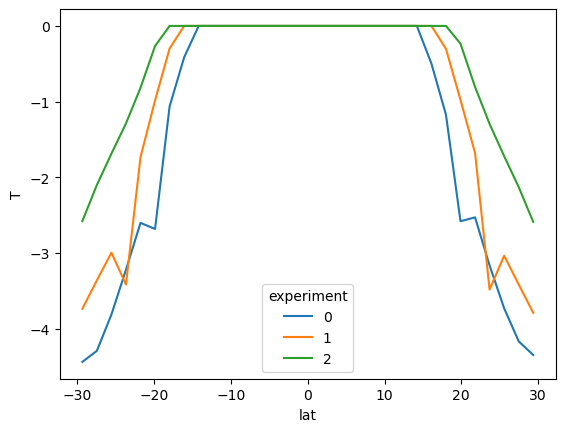

In [ ]:
# multi_experiment_climatological_CIN.plot(x='lat', hue='experiment')

# Local CAPE

In [ ]:
# CAPE, CIN = xr.zeros_like(Td).isel(plev=-1, drop=True), xr.zeros_like(Td).isel(plev=-1, drop=True)

start_time = current_time()
##############
# 1. Load data
#################
dir_in = '/glade/campaign/univ/uwas0114/processed_pcoord/'
expname_list = list(['-4K','CTL','4K'])
fout_list = list(['m4K','ctl','p4K'])

Ptop_all = np.array([75, 100, 125])*100 # Find tropoppause for each exp!

iexp = 0

dir_in_sub = dir_in + fout_list[iexp]+'/'

# for iyr in range(3, 6):#6): # 3, 6
iyr = 3

yy_str = f"{iyr:04d}"
logger.info('Start calculating CAPE for :'+ expname_list[iexp]+','+yy_str)

latitude_bounds = slice(-15,15) # narrow lat band for CAPE calculation
# Load T
fname = dir_in_sub + fout_list[iexp]+'_T_yr'+yy_str+'.nc'
ds    = xr.open_dataset(fname).sel(lat=latitude_bounds)
T = ds['T'].sel(lat=latitude_bounds)
time = ds['time']
lat  = ds['lat']
lon  = ds['lon']
plev = ds['plev']
logger.info('T loaded')

# Load q
fname = dir_in_sub + fout_list[iexp]+'_Q_yr'+yy_str+'.nc'
ds    = xr.open_dataset(fname).sel(lat=latitude_bounds)
q = ds['Q']
logger.info('Q loaded')

# Define CC equation
epsilon = 0.622
e = 6.1094*np.exp( 17.625*(T-273.15)/(T-273.15+243.04) ) # hPa
# plev_large = np.tile(plev, (np.size(T,0), np.size(T, 1), np.size(T, 2), 1))
# print(np.shape(plev_large))
#for ilev in range(0, np.size(plev)):
#    if ilev == 0:
#        RH = np.empty([np.size(T,0), np.size(T, 1), np.size(T, 2), np.size(T, 3)])
RH = q/( epsilon*e/e.plev )
logger.info("RH calculated")

del q
# Calculate CAPE
RH_r = RH[:,:,:,::-1] * units.dimensionless
del RH
T_C = (T[:,:,:,::-1] - 273.15) * units.degC # unit C
plev_r = plev[::-1] * units.hPa
# plev_large_r = plev_large[:,:,:,::-1] * units.hPa

del T

# calculate dewpoint
Td = dewpoint_from_relative_humidity(T_C, RH_r)
del RH_r
logger.info("Dewpoint calculated")

CAPE = xr.zeros_like(T_C.isel(plev=0, drop=True))
CIN = xr.zeros_like(T_C.isel(plev=0, drop=True))

# compute parcel temperature
logger.info("Computing parcel temperatures...")
for it in range(0, np.size(Td,0)):
# for it in range(109*24//3, np.size(Td,0)):
# for it in range(359*24//3, np.size(Td,0)):
    if (it+1) % 40 == 0:
        logger.info(f"Day {3*(it+1)/24}/{int(3*np.size(Td,0)/24)}")

    # for ilat in range(0, np.size(Td, 1)):
    # ilat = 0
    for ilon in range(0, np.size(Td, 2)):
        lowest_valid_plev = T_C.notnull().idxmax('plev')
        T_parc = parcel_profile(
            plev_r.sel(plev=slice(lowest_valid_plev[it,ilat,ilon], None)),
            T_C[it,ilat,ilon].sel(plev=lowest_valid_plev[it,ilat,ilon]),
            Td[it,ilat,ilon].sel(plev=lowest_valid_plev[it,ilat,ilon])
        )
        T_parc_C = (T_parc.values - 273.15)* units.degC
        CAPE_col, CIN_col = cape_cin(
            plev_r.sel(plev=slice(lowest_valid_plev[it,ilat,ilon], None)),
            T_C[it,ilat,ilon].sel(plev=slice(lowest_valid_plev[it,ilat,ilon], None)),
            Td[it,ilat,ilon].sel(plev=slice(lowest_valid_plev[it,ilat,ilon], None)),
            T_parc_C
        )
        CAPE[it,ilat,ilon] = CAPE_col.magnitude
        CIN[it,ilat,ilon] = CIN_col.magnitude
        
        # if np.isnan(T_C[it,ilat,ilon,0]) or np.isnan(Td[it,ilat,ilon,0]):
        #     logger.warning(f"NaN values at time index {it}, lat index {ilat}, lon index {ilon}")

        #     CAPE[it,ilat,ilon] = np.nan
        #     CIN[it,ilat,ilon] = np.nan
        #     continue
        
        # T_parc = parcel_profile(plev_r, T_C[it,ilat,ilon,0], Td[it,ilat,ilon,0])#.to('degC')
        # T_parc_C = (T_parc.values - 273.15)* units.degC
        # CAPE_col, CIN_col = cape_cin(plev_r, T_C[it,ilat,ilon], Td[it,ilat,ilon], T_parc_C)
        # CAPE[it,ilat,ilon] = CAPE_col.magnitude
        # CIN[it,ilat,ilon] = CIN_col.magnitude

#T_parc = parcel_profile(plev_r, T_C[:,:,:,0], Td[:,:,:,0]).to('degC')
logger.info("Parcel temperatures calculated")

# Save CAPE CIN
# dir_out = '/glade/work/muting/KW/output_data/Paper4_revision/CAPE_CIN/'
dir_out = '/glade/u/home/sressel/spencer-scratch/CAPE_CIN/'
os.makedirs(dir_out, exist_ok=True)
fname_out = dir_out + 'CAPE_CIN_'+fout_list[iexp]+'_yr'+yy_str+'_6SN_interactive.nc'
da_CAPE = xr.DataArray(CAPE,\
    coords={"time": time, "lat": lat, "lon": lon},\
    dims=("time", "lat", "lon"), name="CAPE")

da_CIN = xr.DataArray(CIN,\
    coords={"time": time, "lat": lat, "lon": lon},\
    dims=("time", "lat", "lon"), name="CIN")

# ds_out = xr.Dataset({"CAPE": (['time', 'lat', 'lon'], da_CAPE.data)},{"CIN": (['time', 'lat', 'lon'], da_CIN.data)},\
#     coords={'time': ds.time.values, 'lat': ds.lat.values, 'lon': ds.lon.values})
ds_out = xr.Dataset({"CAPE": (['time', 'lat', 'lon'], da_CAPE.data), "CIN": (['time', 'lat', 'lon'], da_CIN.data)},coords={'time': ds.time.values, 'lat': ds.lat.values, 'lon': ds.lon.values})
# ds_out.to_netcdf(fname_out)

end_time = current_time()
logger.info('Finish calculating CAPE_CIN for :'+ expname_list[iexp]+','+yy_str)
logger.info(f"Total time taken: {seconds_to_hms(end_time - start_time)}")

2026-05-05 14:42:21,562 [INFO] Start calculating CAPE for :-4K,0003
2026-05-05 14:42:21,687 [INFO] T loaded
2026-05-05 14:42:21,762 [INFO] Q loaded
2026-05-05 14:42:24,486 [INFO] RH calculated
/glade/u/home/sressel/.conda/envs/modified-npl/lib/python3.12/site-packages/metpy/calc/thermo.py:1403: RuntimeWarning: divide by zero encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)
/glade/u/home/sressel/.conda/envs/modified-npl/lib/python3.12/site-packages/metpy/calc/thermo.py:1404: RuntimeWarning: invalid value encountered in divide
  return mpconsts.nounit.zero_degc + 243.5 * val / (17.67 - val)
2026-05-05 14:42:27,582 [INFO] Dewpoint calculated
2026-05-05 14:42:27,599 [INFO] Computing parcel temperatures...
2026-05-05 15:27:53,374 [INFO] Day 5.0/365


KeyboardInterrupt: 

In [ ]:
# i,j,k = 0, 0, 2
# lowest_valid_plev = T_C.notnull().idxmax('plev')
# print(lowest_valid_plev[i,j,k])
# T_parc_test = parcel_profile(
#     plev_r.sel(plev=slice(lowest_valid_plev[i,j,k], None)),
#     T_C[i,j,k].sel(plev=lowest_valid_plev[i,j,k]),
#     Td[i,j,k].sel(plev=lowest_valid_plev[i,j,k])
# )
# cape_test = cape_cin(
#     plev_r.sel(plev=slice(lowest_valid_plev[i,j,k], None)),
#     T_C[i,j,k].sel(plev=slice(lowest_valid_plev[i,j,k], None)),
#     Td[i,j,k].sel(plev=slice(lowest_valid_plev[i,j,k], None)),
#     T_parc_test
#     )
# CAPE[it,ilat,ilon] = CAPE_col.magnitude

<xarray.DataArray 'plev' ()> Size: 8B
array(1000)
Coordinates:
    time     int64 8B 0
    lat      float64 8B -2.842
    lon      float64 8B 5.0


In [68]:
[(f"{Q.sel(lat=lat).lat:0.0f}").replace("-", "m") for lat in Q.sel(lat=slice(-15,15)).lat][4]

'm7'

In [70]:
logger.info(f'Start calculating CAPE for :{expname_list[iexp]},{yy_str},{lat[ilat].values:0.2f}')

2026-05-05 16:00:30,499 [INFO] Start calculating CAPE for :-4K,0003,2.84
